In [1]:
# === ONLY install cell. Run once, RESTART KERNEL, then run imports. ===
%pip install --upgrade pip
%pip install -U "typing_extensions>=4.10.0"

# Torch 2.7+ — needed for torch.float8_e8m0fnu that current transformers references.
# cu128 wheels cover the L40S. This REPLACES the old cu124 line that capped you at 2.6.
%pip install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

# Everything the notebook imports, one resolve, bitsandbytes last so it matches torch.
# No transformer-lens pin — sae-lens pulls its own compatible version.
%pip install -U sae-lens transformers accelerate datasets hf_transfer bitsandbytes
%pip install -U matplotlib tqdm scipy seaborn scikit-learn numpy statsmodels

print("Install done. RESTART THE KERNEL now, then run the imports cell.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 23.2 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.2
    Uninstalling pip-24.2:
      Successfully uninstalled pip-24.2
Note: you may need to restart the kernel to use updated packages.
  Attempting uninstall: typing_extensions
    Found existing installation: typing_extensions 4.9.0
    Uninstalling typing_extensions-4.9.0:
      Successfully uninstalled typing_extensions-4.9.0
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 657.9/657.9 MB 81.6 MB/s  0:00:08:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.2/287.2 MB 87.3 MB/s  0:00:03ta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.8/296.8 MB 79.0 MB/s  0:00:03:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.1/139.1 MB 79.5 MB/s  0:00:01ta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
import torch
print(torch.__version__, "| float8_e8m0fnu present:", hasattr(torch, "float8_e8m0fnu"))
print("CUDA:", torch.cuda.is_available())

2.11.0+cu128 | float8_e8m0fnu present: True
CUDA: True


In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer
from sae_lens import SAE
from datasets import load_dataset
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import re
import gc

In [3]:
from huggingface_hub import login
login()

In [4]:
# Setup device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

MODEL_A_ID = "google/gemma-2-2b"     
MODEL_B_ID = "google/gemma-2-9b"    

# Fixed layer pair based on previous calculations
STITCH_LAYER_A = 20   # Gemma 2B layer 20
STITCH_LAYER_B = 30  # Gemma 9B layer 30

SAE_A_RELEASE = "gemma-scope-2b-pt-res-canonical"
SAE_A_ID = f"layer_{STITCH_LAYER_A}/width_16k/canonical"  
SAE_B_RELEASE = "gemma-scope-9b-pt-res-canonical" 
SAE_B_ID = f"layer_{STITCH_LAYER_B}/width_16k/canonical" 

# [Phase 0] Oracle deltas are now collected from GSM8K-train (indices 0..N_ORACLE_SAMPLES-1),
# which is disjoint from the GSM8K test split used for evaluation.
# [Phase 1] Training data switched from OpenWebText to GSM8K-train.
TRAINING_DATASET = "openai/gsm8k"          # replaces NeelNanda/openwebtext-tokenized-9b
TRAINING_DATASET_CONFIG = "main"
TRAINING_SPLIT = "train"            # GSM8K train has ~7.5k examples
N_TRAINING_SAMPLES = 5000           # how many GSM8K-train examples to tokenize

CONTEXT_LENGTH = 128
BATCH_SIZE = 4  
NUM_EPOCHS = 8   
LEARNING_RATE = 1e-4
ACTIVATION_CACHE_SIZE = 5_000  
NUM_SAMPLES_FOR_SVCCA = 200  

# ── Phase 1 training config flags ──────────────────────────────────────────
# Bottleneck width (Phase 3 sweep: try 32, 64, 128, 256)
BOTTLENECK_DIM = 64

# Set to 0.0 to use KL-only loss (recommended default per analysis in doc).
# Set to 0.5 to restore original cycle-consistency weighting for ablation.
# Phase 3 ablation: run with CYCLE_LOSS_WEIGHT=0.5 to compare curves.
CYCLE_LOSS_WEIGHT = 0.0

# Random per-batch strength sampling range (uniform draw each batch).
# Recommended: [0.3, 1.0]. Matches the hook used at eval time.
STRENGTH_SAMPLE_MIN = 0.3
STRENGTH_SAMPLE_MAX = 1.0

# Oracle-in-training: keep False so the trained stitch isn't coupled to a
# specific oracle rank -> Phase 3's rank sweep works from one trained stitch.
# Flip to True in Phase 3 if you want to test oracle-guided training.
APPLY_ORACLE_IN_TRAINING = False

# Number of GSM8K-train samples used for oracle delta collection (Phase 0).
# These indices MUST NOT overlap with evaluation indices (GSM8K test split).
# GSM8K train and test are separate HF splits, so there is zero overlap.
N_ORACLE_SAMPLES = 100


ORACLE_RANK_FOR_TRAINING = 32   # set based on Phase 1 sweep results

Using device: cuda


In [5]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch

print("Loading tokenizer and models...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_A_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'left'   # required for correct batched generate at eval

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True
)

# Load Model A (2B model)
print(f"Loading {MODEL_A_ID}...")
model_a = AutoModelForCausalLM.from_pretrained(
    MODEL_A_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    low_cpu_mem_usage=True
)

# Load Model B (9B model)
print(f"Loading {MODEL_B_ID}...")
model_b = AutoModelForCausalLM.from_pretrained(
    MODEL_B_ID,
    torch_dtype=torch.bfloat16,
    quantization_config=bnb_config,  # <-- NEW WAY TO PASS 4-BIT PARAMS
    device_map="auto",
    low_cpu_mem_usage=True
)

print("Models and tokenizer loaded successfully.")
print(f"Using fixed layer pair: Gemma 2B Layer {STITCH_LAYER_A} → Gemma 9B Layer {STITCH_LAYER_B}")

def get_unnormalized_activations(model, tokens, layer_idx, return_all_positions=False):
    """
    Get unnormalized activations. Can return all positions or just the last token.
    """
    with torch.no_grad():
        # Handle different model architectures
        if hasattr(model, 'model'):
            # For Gemma models
            outputs = model.model(tokens, output_hidden_states=True)
        else:
            outputs = model(tokens, output_hidden_states=True)
        
        # Shape: [batch_size, seq_len, hidden_dim]
        all_activations = outputs.hidden_states[layer_idx].to(torch.float32)
        
        if return_all_positions:
            # Return all sequence positions: [batch_size * seq_len, hidden_dim]
            batch_size, seq_len, hidden_dim = all_activations.shape
            return all_activations.view(-1, hidden_dim).cpu()
        else:
            # Return only last token: [batch_size, hidden_dim] 
            return all_activations[:, -1].cpu()

def get_normalized_activations(model, tokens, layer_idx, return_all_positions=False):
    """
    Get normalized activations. Can return all positions or just the last token.
    """
    with torch.no_grad():
        if hasattr(model, 'model'):
            outputs = model.model(tokens, output_hidden_states=True)
        else:
            outputs = model(tokens, output_hidden_states=True)
            
        # Shape: [batch_size, seq_len, hidden_dim]
        all_activations = outputs.hidden_states[layer_idx].to(torch.float32)
        
        if return_all_positions:
            # Normalize per position, return all: [batch_size * seq_len, hidden_dim]
            batch_size, seq_len, hidden_dim = all_activations.shape
            # Reshape to process all positions at once
            reshaped = all_activations.view(-1, hidden_dim)
            normalized = torch.nn.functional.layer_norm(reshaped, [hidden_dim])
            return normalized.cpu()
        else:
            # Normalize and return only last token: [batch_size, hidden_dim]
            last_token_acts = all_activations[:, -1]  
            normalized_activations = torch.nn.functional.layer_norm(last_token_acts, [last_token_acts.shape[-1]])
            return normalized_activations.cpu()
        
        
def get_sae_features(model, sae, tokens, layer_idx):
    """Get SAE feature activations instead of raw activations"""
    with torch.no_grad():
        # Get unnormalized activations (SAEs expect these)
        if hasattr(model, 'model'):
            outputs = model.model(tokens, output_hidden_states=True)
        else:
            outputs = model(tokens, output_hidden_states=True)
        
        activations = outputs.hidden_states[layer_idx].to(torch.float32)
        
        # Encode through SAE to get features
        features = sae.encode(activations[:, -1])  # [batch, d_sae]
        return features.cpu()



def centered_kernel_alignment(acts_a, acts_b, device):
    """
    Centered Kernel Alignment (CKA) for similarity measurement
    """
    acts_a = acts_a.to(device)
    acts_b = acts_b.to(device)
    
    # Center the data
    acts_a = acts_a - acts_a.mean(dim=0, keepdim=True)
    acts_b = acts_b - acts_b.mean(dim=0, keepdim=True)
    
    # Compute Gram matrices
    gram_a = torch.mm(acts_a, acts_a.T)
    gram_b = torch.mm(acts_b, acts_b.T)
    
    # Center the Gram matrices
    n = gram_a.shape[0]
    H = torch.eye(n, device=device) - torch.ones(n, n, device=device) / n
    gram_a_centered = torch.mm(torch.mm(H, gram_a), H)
    gram_b_centered = torch.mm(torch.mm(H, gram_b), H)
    
    # CKA formula
    numerator = torch.trace(torch.mm(gram_a_centered, gram_b_centered))
    denominator = torch.sqrt(torch.trace(torch.mm(gram_a_centered, gram_a_centered)) * 
                           torch.trace(torch.mm(gram_b_centered, gram_b_centered)))
    
    if denominator > 1e-8:
        cka_score = (numerator / denominator).item()
    else:
        cka_score = 0.0
    
    return abs(cka_score)

class ActivationDataset(Dataset):
    def __init__(self, acts_a_tensor, acts_b_tensor):
        self.acts_a = acts_a_tensor
        self.acts_b = acts_b_tensor
    
    def __len__(self): 
        return self.acts_a.shape[0]
    
    def __getitem__(self, idx): 
        return self.acts_a[idx], self.acts_b[idx]

print("Loading Gemma Scope SAEs for evaluation...")

try:
    print(f"Loading SAE A: {SAE_A_RELEASE}/{SAE_A_ID}")
    sae_a: SAE = SAE.from_pretrained(release=SAE_A_RELEASE, sae_id=SAE_A_ID, device=device)
    
    print(f"Loading SAE B: {SAE_B_RELEASE}/{SAE_B_ID}")
    sae_b: SAE = SAE.from_pretrained(release=SAE_B_RELEASE, sae_id=SAE_B_ID, device=device)
    
    print("SAEs loaded successfully!")
    print(f"SAE A (Layer {STITCH_LAYER_A}): d_in={sae_a.cfg.d_in}, d_sae={sae_a.cfg.d_sae}")
    print(f"SAE B (Layer {STITCH_LAYER_B}): d_in={sae_b.cfg.d_in}, d_sae={sae_b.cfg.d_sae}")
    
except Exception as e:
    print(f"Warning: Could not load SAEs - {e}")
    print("Evaluation will proceed without SAE reconstruction")
    sae_a, sae_b = None, None


# Freeze base models and SAEs (New with KL divergence updates)
print("Freezing base models and SAEs:")

for param in sae_a.parameters():
    param.requires_grad = False
for param in sae_b.parameters():
    param.requires_grad = False
for param in model_a.parameters():
    param.requires_grad = False
for param in model_b.parameters():
    param.requires_grad = False

print("All base model and SAE parameters frozen.")

Loading tokenizer and models...


config.json:   0%|          | 0.00/818 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/46.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

...

Models and tokenizer loaded successfully.
Using fixed layer pair: Gemma 2B Layer 20 → Gemma 9B Layer 30
Loading Gemma Scope SAEs for evaluation...
Loading SAE A: gemma-scope-2b-pt-res-canonical/layer_20/width_16k/canonical


layer_20/width_16k/average_l0_71/params.(…):   0%|          | 0.00/302M [00:00<?, ?B/s]

Loading SAE B: gemma-scope-9b-pt-res-canonical/layer_30/width_16k/canonical


layer_30/width_16k/average_l0_120/params(…):   0%|          | 0.00/470M [00:00<?, ?B/s]

SAEs loaded successfully!
SAE A (Layer 20): d_in=2304, d_sae=16384
SAE B (Layer 30): d_in=3584, d_sae=16384
Freezing base models and SAEs:
All base model and SAE parameters frozen.


In [6]:
# Fixed GSM8K prompt + numeric extraction

import re
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

MAX_NEW_TOKENS = 400
EVAL_BATCH_SIZE = 8
grafting_context = {}


def generate_gsm8k_prompt(question):
    """
    Few-shot prompt with worked example.
    use the #### format for final answers.
    """
    prompt = (
        "Below are math problems with detailed step-by-step solutions.\n\n"
        "Problem: Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. "
        "How many clips did Natalia sell altogether in April and May?\n"
        "Solution: Let's think step-by-step.\n"
        "1. Clips sold in April: 48\n"
        "2. Clips sold in May: 48 / 2 = 24\n"
        "3. Total clips: 48 + 24 = 72\n"
        "#### 72\n\n"
        f"Problem: {question}\n"
        "Solution: Let's think step-by-step."
    )
    return prompt


def extract_numerical_answer(text):
    """
    Handles standard GSM8K #### format,
    'the answer is X', and last-number fallback.
    """
    # Standard GSM8K format: #### 123
    ans_match = re.search(r"####\s*(-?[\d,.]+)", text)
    if ans_match:
        ans_str = ans_match.group(1).replace(",", "")
        try:
            return float(ans_str)
        except ValueError:
            pass

    # Fallback: 'The answer is X'
    ans_match = re.search(r"answer is\s*(-?[\d,.]+)", text, re.IGNORECASE)
    if ans_match:
        ans_str = ans_match.group(1).replace(",", "")
        try:
            return float(ans_str)
        except ValueError:
            pass

    # Final fallback: last number in the entire text
    numbers = re.findall(r"-?[\d,.]+", text)
    if numbers:
        last_num = numbers[-1].rstrip('.').replace(",", "")
        try:
            return float(last_num)
        except ValueError:
            return None

    return None


print("Corrected eval functions defined.")

Corrected eval functions defined.


In [7]:
# ============================================================================
# MULTI-LAYER LINEAR STITCH  (GSM8K)            -- two appendable notebook cells
# ============================================================================
# Append these AFTER your existing setup cells. Prerequisites already defined by
# your notebook (cells 5-8 of SAE_Negative_Case_Result):
#     model_a (gemma-2-2b, bf16)   model_b (gemma-2-9b, 4bit)   tokenizer
#     device   STITCH_LAYER_A (=20)   generate_gsm8k_prompt()   extract_numerical_answer()
#     grafting_context (dict)   MAX_NEW_TOKENS   EVAL_BATCH_SIZE
# No SAE, no training. This is the single-layer linear stitch generalised to a
# BAND of layers, with the single-layer (20<-34) condition run alongside on the
# SAME eval samples so the comparison is within-run.
#
# Question: does transplanting the 9B's multi-LAYER trajectory (not just one
# layer) lift GSM8K above the 2B baseline? If single ~= multi and both sit at
# baseline with high per-layer recon_cos, the ceiling is the 2B's own machinery,
# and the "one layer can't carry a multi-step computation" objection is dead.
 
# === CELL A : fit one ridge map per (2B<-9B) layer pair on GSM8K-train ===
import torch
from datasets import load_dataset
from tqdm.auto import tqdm
 
LAYER_PAIRS  = [(18, 31), (20, 34), (22, 37), (24, 40)]   # (2B graft, 9B donor)
SINGLE_LA    = STITCH_LAYER_A                              # 20, the single-layer baseline
N_FIT_PROMPTS = 150
MAX_FIT_ROWS  = 20000
RIDGE_LAMBDA  = 1e3
RECON_HELDOUT = 40
 
LA_LIST = [p[0] for p in LAYER_PAIRS]
LB_OF   = {a: b for a, b in LAYER_PAIRS}
assert SINGLE_LA in LA_LIST, "single-layer baseline must be one of the pairs"
 
 
def _collect_multi(prompts, la_list, lb_list, batch_size=4, max_rows=None):
    """One pass per model; returns X9[lb] and X2[la] over non-pad positions."""
    X9 = {lb: [] for lb in lb_list}
    X2 = {la: [] for la in la_list}
    rows = 0
    model_a.eval(); model_b.eval()
    base_b = model_b.model if hasattr(model_b, 'model') else model_b
    base_a = model_a.model if hasattr(model_a, 'model') else model_a
    for i in tqdm(range(0, len(prompts), batch_size), desc="collect pairs"):
        enc = tokenizer(prompts[i:i + batch_size], return_tensors="pt", padding=True,
                        truncation=True, max_length=512).to(device)
        m = enc['attention_mask'].bool()
        with torch.no_grad():
            hb = base_b(enc['input_ids'], attention_mask=enc['attention_mask'],
                        output_hidden_states=True).hidden_states
            ha = base_a(enc['input_ids'], attention_mask=enc['attention_mask'],
                        output_hidden_states=True).hidden_states
        for lb in lb_list:
            X9[lb].append(hb[lb + 1].float()[m].cpu())
        for la in la_list:
            X2[la].append(ha[la + 1].float()[m].cpu())
        rows += int(m.sum())
        if max_rows and rows >= max_rows:
            break
    return ({lb: torch.cat(v) for lb, v in X9.items()},
            {la: torch.cat(v) for la, v in X2.items()})
 
 
class LinearStitch:
    def __init__(self, W, mu9, mu2, dev):
        self.W = W.to(dev); self.mu9 = mu9.to(dev); self.mu2 = mu2.to(dev)
    def __call__(self, x):
        x = x.float().to(self.W.device)
        return (x - self.mu9) @ self.W + self.mu2
 
 
_train = list(load_dataset("openai/gsm8k", "main", split="train")
              .select(range(N_FIT_PROMPTS + RECON_HELDOUT)))
_fit   = [generate_gsm8k_prompt(x['question']) for x in _train[:N_FIT_PROMPTS]]
_held  = [generate_gsm8k_prompt(x['question']) for x in _train[N_FIT_PROMPTS:]]
 
print(f"Fitting {len(LAYER_PAIRS)} ridge maps on GSM8K-train: {LAYER_PAIRS}")
X9, X2 = _collect_multi(_fit, LA_LIST, [LB_OF[a] for a in LA_LIST], max_rows=MAX_FIT_ROWS)
print(f"  fit rows: {next(iter(X2.values())).shape[0]}")
 
stitches = {}
for la in LA_LIST:
    lb = LB_OF[la]
    mu9, mu2 = X9[lb].mean(0), X2[la].mean(0)
    A, B = X9[lb] - mu9, X2[la] - mu2
    W = torch.linalg.solve(A.T @ A + RIDGE_LAMBDA * torch.eye(A.shape[1]), A.T @ B)
    stitches[la] = LinearStitch(W, mu9, mu2, device)
print("  maps fit.")
 
# per-layer recon_cos on held-out GSM8K-train
H9, H2 = _collect_multi(_held, LA_LIST, [LB_OF[a] for a in LA_LIST])
recon_cos = {}
for la in LA_LIST:
    mapped = stitches[la](H9[LB_OF[la]]).cpu()
    recon_cos[la] = torch.nn.functional.cosine_similarity(mapped, H2[la], dim=1).mean().item()
print("\nper-layer recon_cos (mapped 9B vs 2B's own state):")
for la in LA_LIST:
    print(f"  2B L{la} <- 9B L{LB_OF[la]} : {recon_cos[la]:.3f}")
del X9, X2, H9, H2; torch.cuda.empty_cache()

README.md:   0%|          | 0.00/7.93k [00:00<?, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

Fitting 4 ridge maps on GSM8K-train: [(18, 31), (20, 34), (22, 37), (24, 40)]


collect pairs:   0%|          | 0/38 [00:00<?, ?it/s]

  fit rows: 20290
  maps fit.


collect pairs:   0%|          | 0/10 [00:00<?, ?it/s]


per-layer recon_cos (mapped 9B vs 2B's own state):
  2B L18 <- 9B L31 : 0.954
  2B L20 <- 9B L34 : 0.953
  2B L22 <- 9B L37 : 0.950
  2B L24 <- 9B L40 : 0.952


base:   0%|          | 0/25 [00:00<?, ?it/s]

-> base: acc = 0.275 (55/200)


single s=0.5:   0%|          | 0/25 [00:00<?, ?it/s]

-> single s=0.5: acc = 0.245 (49/200)


multi s=0.5:   0%|          | 0/25 [00:00<?, ?it/s]

-> multi s=0.5: acc = 0.255 (51/200)


single s=1.0:   0%|          | 0/25 [00:00<?, ?it/s]

-> single s=1.0: acc = 0.270 (54/200)


multi s=1.0:   0%|          | 0/25 [00:00<?, ?it/s]

-> multi s=1.0: acc = 0.270 (54/200)

=== MULTI-LAYER vs SINGLE-LAYER linear stitch (GSM8K) ===
per-layer recon_cos: {'L18': 0.954, 'L20': 0.953, 'L22': 0.95, 'L24': 0.952}
  baseline (s=0)        : 0.275
  single (L20)  s=0.5: 0.245   multi ([18, 20, 22, 24]) s=0.5: 0.255
  single (L20)  s=1.0: 0.270   multi ([18, 20, 22, 24]) s=1.0: 0.270

 single ~= multi ~= baseline -> competence ceiling, layer count is not the bottleneck.
 multi > single             -> more layers confer more; single-layer was limiting.
saved multilayer_gsm8k_results.json + multilayer_gsm8k.png


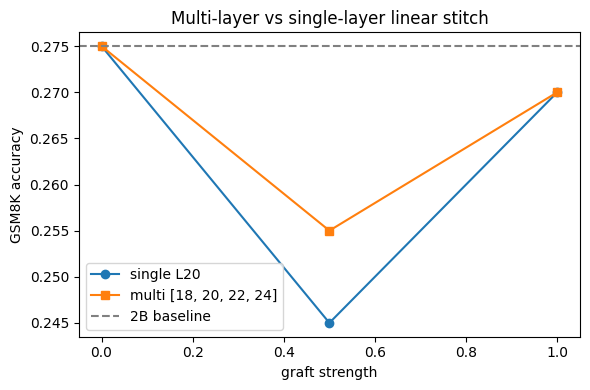

In [8]:
# === CELL B : evaluate single-layer vs multi-layer, strength sweep ===
import json
import matplotlib.pyplot as plt
from datasets import load_dataset
 
 
def make_multilayer_hook(layer_a):
    """Blend (1-s)*orig + s*mapped-9B at this layer; no-ops off-prefill & at s=0."""
    def hook(module, args, output):
        is_tuple = isinstance(output, tuple)
        orig = output[0] if is_tuple else output
        s = grafting_context.get('strength', 0.0)
        gd = grafting_context.get('grafted', None)
        if s == 0.0 or not gd or gd.get(layer_a) is None:
            return output
        graft = gd[layer_a]
        if orig.shape[1] != graft.shape[1]:          # only matched-length prefill
            return output
        td = next(module.parameters()).dtype
        of = orig.float(); gf = graft.float().to(of.device)
        mod = ((1.0 - s) * of + s * gf).to(td)
        return (mod,) + output[1:] if is_tuple else mod
    return hook
 
 
def evaluate_gsm8k_multilayer(active, samples, strength=1.0, batch_size=EVAL_BATCH_SIZE):
    """active: set of 2B layers to graft this run. strength 0 -> pure baseline."""
    base_b = model_b.model if hasattr(model_b, 'model') else model_b
    handles = []
    for la in LA_LIST:                                # register on the whole band;
        model_a.model.layers[la]._forward_hooks.clear()
        handles.append(model_a.model.layers[la].register_forward_hook(
            make_multilayer_hook(la)))                # inactive layers no-op via the dict
    grafting_context['strength'] = strength
    model_a.eval(); model_b.eval()
    correct = total = 0
    try:
        tag = "base" if strength == 0 else f"{'single' if active=={SINGLE_LA} else 'multi'} s={strength}"
        for i in tqdm(range(0, len(samples), batch_size), desc=tag):
            b = samples[i:i + batch_size]
            prompts = [generate_gsm8k_prompt(x['question']) for x in b]
            gold = [extract_numerical_answer(x['answer']) for x in b]
            inp = tokenizer(prompts, return_tensors="pt", padding=True,
                            truncation=True, max_length=512).to(device)
            with torch.no_grad():
                if strength > 0.0:
                    ob = base_b(inp['input_ids'], attention_mask=inp['attention_mask'],
                                output_hidden_states=True)
                    grafting_context['grafted'] = {
                        la: stitches[la](ob.hidden_states[LB_OF[la] + 1])
                        for la in active}
                else:
                    grafting_context['grafted'] = None
                gen = model_a.generate(**inp, max_new_tokens=MAX_NEW_TOKENS,
                                       do_sample=False, pad_token_id=tokenizer.eos_token_id)
            resp = tokenizer.batch_decode(gen[:, inp['input_ids'].shape[1]:],
                                          skip_special_tokens=True)
            for j, r in enumerate(resp):
                p = extract_numerical_answer(r)
                correct += int(p is not None and gold[j] is not None and abs(p - gold[j]) < 0.01)
                total += 1
    finally:
        for h in handles:
            h.remove()
        grafting_context.update(strength=0.0, grafted=None)
    acc = correct / total if total else 0.0
    print(f"-> {tag}: acc = {acc:.3f} ({correct}/{total})")
    return acc
 
 
eval_samples = list(load_dataset("openai/gsm8k", "main", split="test").select(range(200)))
STRENGTHS = [0.5, 1.0]
single_set = {SINGLE_LA}
multi_set  = set(LA_LIST)
 
results = {"baseline": evaluate_gsm8k_multilayer(single_set, eval_samples, strength=0.0)}
for s in STRENGTHS:
    results[f"single_{s}"] = evaluate_gsm8k_multilayer(single_set, eval_samples, strength=s)
    results[f"multi_{s}"]  = evaluate_gsm8k_multilayer(multi_set,  eval_samples, strength=s)
 
print("\n=== MULTI-LAYER vs SINGLE-LAYER linear stitch (GSM8K) ===")
print("per-layer recon_cos:", {f"L{la}": round(recon_cos[la], 3) for la in LA_LIST})
print(f"  baseline (s=0)        : {results['baseline']:.3f}")
for s in STRENGTHS:
    print(f"  single (L{SINGLE_LA})  s={s}: {results[f'single_{s}']:.3f}   "
          f"multi ({LA_LIST}) s={s}: {results[f'multi_{s}']:.3f}")
print("\n single ~= multi ~= baseline -> competence ceiling, layer count is not the bottleneck.")
print(" multi > single             -> more layers confer more; single-layer was limiting.")
 
xs = [0.0] + STRENGTHS
plt.figure(figsize=(6, 4))
plt.plot(xs, [results['baseline']] + [results[f'single_{s}'] for s in STRENGTHS],
         "-o", label=f"single L{SINGLE_LA}")
plt.plot(xs, [results['baseline']] + [results[f'multi_{s}'] for s in STRENGTHS],
         "-s", label=f"multi {LA_LIST}")
plt.axhline(results['baseline'], ls="--", c="gray", label="2B baseline")
plt.xlabel("graft strength"); plt.ylabel("GSM8K accuracy")
plt.title("Multi-layer vs single-layer linear stitch")
plt.legend(); plt.tight_layout(); plt.savefig("multilayer_gsm8k.png", dpi=140)
 
json.dump({"recon_cos": recon_cos, "results": results,
           "layer_pairs": LAYER_PAIRS, "single_la": SINGLE_LA},
          open("multilayer_gsm8k_results.json", "w"), indent=2)
print("saved multilayer_gsm8k_results.json + multilayer_gsm8k.png")

In [9]:
# ============================================================================
# TASK-SUPERVISED vs RECONSTRUCTION cross-model map  (arithmetic)
# ---------------------------------------------------------------------------
# Appendable notebook cells. Reuses what you already have loaded:
#     model_a (gemma-2-2b, bf16)   model_b (gemma-2-9b, 4bit)
#     tokenizer (padding_side='left')   device
# Nothing reloads. Paste these after your current cells and run T0 -> T4 in order.
#
# QUESTION (the one behind "are these just no-ops?"):
#   A reconstruction map lands on the 2B's own manifold by construction, so it
#   can only reproduce the 2B's own answer -> no confer. Does a map *optimized
#   against the task* (free to leave the manifold) confer the 9B's answer on
#   problems the 2B natively fails?
#     task-map confers on UNSOLVABLE  -> capability is reachable in the 2B's
#         back half; reconstruction-universality just can't access it.
#     task-map ALSO fails             -> ceiling is real; no linear image of the
#         9B state drives the 2B's outputs to the answer.
#   Controls: shuffled-donor task map (is confer donor-specific?) + a linear
#   probe (is the answer even linearly present in the 9B donor state?).
# ============================================================================
 
# === CELL T0 : config + arithmetic problems ===
import torch, torch.nn.functional as F, random, json
from collections import defaultdict
 
L2        = 20          # 2B graft layer (resid_post[20] = hidden_states[21])
L9_DONOR  = 34          # 9B donor layer (CKA-validated best for 2B-20; set 30 to match SAE)
SEED      = 0
RIDGE_LAMBDA = 1e3
TRAIN_N   = 1200
EVAL_N    = 900
MODES     = ["mul", "muladd"]
FEWSHOT   = ("2 + 5 = 7\n6 * 3 = 18\n4 * 7 + 2 = 30\n9 * 8 = 72\n"
             "3 * 4 + 5 = 17\n40 * 20 = 800\n")
# task-map training
EPOCHS, TBATCH, LR = 6, 16, 1e-3
CBATCH = 16             # collection / eval batch
 
def _expr_ans(mode, a, b, c):
    if mode == "mul":    return f"{a} * {b}", a * b
    return f"{a} * {b} + {c}", a * b + c          # muladd
 
def _sample(mode, rng):
    if mode == "mul":    return rng.randint(11, 99), rng.randint(100, 999), 0
    return rng.randint(2, 40), rng.randint(2, 40), rng.randint(1, 99)
 
def _make_prompt(expr): return f"{FEWSHOT}{expr} ="
 
def _encode(expr, ans):
    base = _make_prompt(expr)
    p = tokenizer(base).input_ids
    f = tokenizer(base + " " + str(ans)).input_ids
    if f[:len(p)] != p or len(f) < len(p) + 2:
        return None, None
    return torch.tensor(f[:len(p) + 1]), f[len(p) + 1]   # ids (1D), first-answer token
 
def gen_problems(n, rng, exclude=None):
    exclude = exclude or set(); out, seen, tries = [], set(), 0
    while len(out) < n and tries < n * 120:
        tries += 1
        mode = rng.choice(MODES); a, b, c = _sample(mode, rng)
        expr, ans = _expr_ans(mode, a, b, c)
        if expr in seen or expr in exclude: continue
        seen.add(expr)
        ids, tok = _encode(expr, ans)
        if tok is None: continue
        out.append(dict(mode=mode, expr=expr, ans=ans, ids=ids, tok=tok))
    return out
 
train = gen_problems(TRAIN_N, random.Random(SEED))
evalp = gen_problems(EVAL_N, random.Random(SEED + 1), {p["expr"] for p in train})
print(f"train {len(train)} | eval {len(evalp)}  (modes {MODES}, donor 9B L{L9_DONOR} -> 2B L{L2})")

train 1200 | eval 900  (modes ['mul', 'muladd'], donor 9B L34 -> 2B L20)


In [10]:
# === CELL T1 : collect states (9B donor, 2B own + native correctness) ===
def left_pad(id_list, pad_id):
    L = max(t.numel() for t in id_list)
    ids = torch.full((len(id_list), L), pad_id, dtype=torch.long)
    mask = torch.zeros((len(id_list), L), dtype=torch.long)
    for i, t in enumerate(id_list):
        t = t.flatten(); ids[i, L - t.numel():] = t; mask[i, L - t.numel():] = 1
    return ids, mask
 
@torch.no_grad()
def collect_states(model, layer, prob_list, batch=CBATCH):
    base = model.model if hasattr(model, "model") else model
    out = []
    for i in range(0, len(prob_list), batch):
        ids, m = left_pad([p["ids"] for p in prob_list[i:i + batch]], tokenizer.pad_token_id)
        hs = base(ids.to(device), attention_mask=m.to(device),
                  output_hidden_states=True).hidden_states[layer + 1]
        out.append(hs[:, -1, :].float().cpu())
    return torch.cat(out)
 
@torch.no_grad()
def native_top(model, prob_list, batch=CBATCH):
    tops = []
    for i in range(0, len(prob_list), batch):
        ids, m = left_pad([p["ids"] for p in prob_list[i:i + batch]], tokenizer.pad_token_id)
        lg = model(ids.to(device), attention_mask=m.to(device)).logits[:, -1, :]
        tops += lg.argmax(-1).cpu().tolist()
    return tops
 
print("9B donor states + correctness ...")
X9_train = collect_states(model_b, L9_DONOR, train)
X9_eval  = collect_states(model_b, L9_DONOR, evalp)
nine_top = native_top(model_b, evalp)
keep = [i for i, p in enumerate(evalp) if nine_top[i] == p["tok"]]
evalp = [evalp[i] for i in keep]; X9_eval = X9_eval[keep]
print(f"  kept {len(evalp)} eval problems the 9B solves")
 
print("2B own states + native correctness ...")
X2_train = collect_states(model_a, L2, train)
X2_eval  = collect_states(model_a, L2, evalp)
two_top  = native_top(model_a, evalp)
solvable = [two_top[i] == evalp[i]["tok"] for i in range(len(evalp))]
print(f"  2B natively solves {sum(solvable)}/{len(evalp)}")
 
mu9, mu2 = X9_train.mean(0), X2_train.mean(0)

9B donor states + correctness ...
  kept 800 eval problems the 9B solves
2B own states + native correctness ...
  2B natively solves 651/800


In [11]:
# === CELL T2 : reconstruction map (closed-form ridge) ===
A_, B_ = X9_train - mu9, X2_train - mu2
W_recon = torch.linalg.solve(A_.T @ A_ + RIDGE_LAMBDA * torch.eye(A_.shape[1]), A_.T @ B_)
print("reconstruction map fit.")
 
 
# === CELL T3 : task-supervised map (GD through frozen 2B, init from recon) ===
graft_ctx = {"vec": None}
 
def graft_hook(_m, _i, o):
    is_t = isinstance(o, tuple); h = o[0] if is_t else o
    vec = graft_ctx["vec"]
    if vec is None or h.shape[1] == 0:
        return o
    h_new = torch.cat([h[:, :-1, :], vec.to(h.dtype).unsqueeze(1)], dim=1)   # graph-safe
    return (h_new,) + o[1:] if is_t else h_new
 
W = W_recon.clone().to(device).requires_grad_(True)
b = mu2.clone().to(device).requires_grad_(True)
mu9d = mu9.to(device)
opt = torch.optim.Adam([W, b], lr=LR)
 
model_a.requires_grad_(False)
handle = model_a.model.layers[L2].register_forward_hook(graft_hook)
idx_all = list(range(len(train)))
try:
    for ep in range(EPOCHS):
        random.Random(ep).shuffle(idx_all)
        tot, nb = 0.0, 0
        for s in range(0, len(idx_all), TBATCH):
            idx = idx_all[s:s + TBATCH]
            x9 = X9_train[idx].to(device)
            mapped = (x9 - mu9d) @ W + b                       # [B, d2], requires grad
            graft_ctx["vec"] = mapped
            ids, m = left_pad([train[k]["ids"] for k in idx], tokenizer.pad_token_id)
            logits = model_a(ids.to(device), attention_mask=m.to(device)).logits[:, -1, :].float()
            target = torch.tensor([train[k]["tok"] for k in idx], device=device)
            loss = F.cross_entropy(logits, target)
            opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item(); nb += 1
        print(f"  epoch {ep}: train CE {tot / nb:.3f}")
finally:
    graft_ctx["vec"] = None; handle.remove(); model_a.requires_grad_(True)
W_task, b_task = W.detach(), b.detach()
print("task-supervised map trained.")

reconstruction map fit.
  epoch 0: train CE 0.509
  epoch 1: train CE 0.301
  epoch 2: train CE 0.183
  epoch 3: train CE 0.150
  epoch 4: train CE 0.101
  epoch 5: train CE 0.112
task-supervised map trained.


In [12]:
# === CELL T4 : evaluate both maps + controls + probe ===
def recon_cos(mapped):                      # cosine to the 2B's OWN clean L2 state
    return F.cosine_similarity(mapped, X2_eval, dim=1)
 
@torch.no_grad()
def confer(map_fn, batch=CBATCH):
    handle = model_a.model.layers[L2].register_forward_hook(graft_hook)
    tops, mapped_all = [], []
    try:
        for i in range(0, len(evalp), batch):
            x9 = X9_eval[i:i + batch].to(device)
            mapped = map_fn(x9); mapped_all.append(mapped.cpu())
            graft_ctx["vec"] = mapped
            ids, m = left_pad([p["ids"] for p in evalp[i:i + batch]], tokenizer.pad_token_id)
            lg = model_a(ids.to(device), attention_mask=m.to(device)).logits[:, -1, :]
            tops += lg.argmax(-1).cpu().tolist()
    finally:
        graft_ctx["vec"] = None; handle.remove()
    return tops, recon_cos(torch.cat(mapped_all))
 
W_recon_d = W_recon.to(device); mu2d = mu2.to(device)
shuf = torch.randperm(len(evalp))
maps = {
    "recon":     lambda x9: (x9 - mu9d) @ W_recon_d + mu2d,
    "task":      lambda x9: (x9 - mu9d) @ W_task + b_task,
}
res = {name: confer(fn) for name, fn in maps.items()}
# shuffled-donor control for the task map (same mapping, wrong problem's 9B state)
res["task_shuf"] = (None, None)
_handle = model_a.model.layers[L2].register_forward_hook(graft_hook)
_tops = []
with torch.no_grad():
    for i in range(0, len(evalp), CBATCH):
        x9 = X9_eval[shuf[i:i + CBATCH]].to(device)
        graft_ctx["vec"] = (x9 - mu9d) @ W_task + b_task
        ids, m = left_pad([p["ids"] for p in evalp[i:i + CBATCH]], tokenizer.pad_token_id)
        _tops += model_a(ids.to(device), attention_mask=m.to(device)).logits[:, -1, :].argmax(-1).cpu().tolist()
graft_ctx["vec"] = None; _handle.remove()
res["task_shuf"] = (_tops, None)
 
# tally per (mode, solvable)
bins = defaultdict(lambda: defaultdict(list))
for i, p in enumerate(evalp):
    key = (p["mode"], solvable[i])
    bins[key]["native"].append(two_top[i] == p["tok"])
    for name in ["recon", "task", "task_shuf"]:
        bins[key][name].append(res[name][0][i] == p["tok"])
rc = {name: res[name][1].mean().item() for name in ["recon", "task"]}
 
# answer-digit linear probe on the 9B donor state (transcription diagnostic)
def first_digit(p): return int(str(abs(p["ans"]))[0])
yt = torch.tensor([first_digit(p) for p in train]); ye = torch.tensor([first_digit(p) for p in evalp])
Pw = torch.zeros(X9_train.shape[1], 10, requires_grad=True)
po = torch.optim.Adam([Pw], lr=1e-2)
Xtr = (X9_train - mu9); Xev = (X9_eval - mu9)
for _ in range(300):
    po.zero_grad(); F.cross_entropy(Xtr @ Pw, yt).backward(); po.step()
probe_acc = (Xev @ Pw.detach()).argmax(1).eq(ye).float().mean().item()
 
def rate(lst): return f"{sum(lst) / len(lst):.2f}" if lst else "n=0"
print("\n=== reconstruction vs task-supervised map: confer by competence ===")
print(f"recon_cos  recon={rc['recon']:.3f}   task={rc['task']:.3f}   "
      f"(task should be LOWER -> it left the manifold)")
print(f"9B first-digit linear-probe acc = {probe_acc:.2f}  "
      f"(high -> answer is linearly in the donor; a task confer is partly transcription)")
for mode in MODES:
    for solv, lab in [(True, "SOLVABLE  "), (False, "UNSOLVABLE")]:
        d = bins[(mode, solv)]
        n = len(d["native"])
        print(f"[{mode}] {lab} n={n:3d} | native {rate(d['native'])} | "
              f"recon-graft {rate(d['recon'])} | task-graft {rate(d['task'])} | "
              f"task-shuf {rate(d['task_shuf'])}")
print("\nread: UNSOLVABLE task-graft >> recon-graft AND >> task-shuf  -> genuine, "
      "donor-specific capability transfer (reconstruction-universality misses it).")
print("      UNSOLVABLE task-graft ~ recon-graft ~ 0                  -> real ceiling; "
      "no linear image of the 9B state drives the 2B to the answer.")
 
out = {"recon_cos": rc, "probe_first_digit_acc": probe_acc,
       "bins": {f"{m}_{'solv' if s else 'unsolv'}":
                {k: (sum(v) / len(v) if v else None) for k, v in d.items()}
                for (m, s), d in bins.items()},
       "counts": {f"{m}_{'solv' if s else 'unsolv'}": len(d["native"])
                  for (m, s), d in bins.items()},
       "L2": L2, "L9_DONOR": L9_DONOR}
json.dump(out, open("task_vs_recon_results.json", "w"), indent=2)
print("\nsaved task_vs_recon_results.json")
 


=== reconstruction vs task-supervised map: confer by competence ===
recon_cos  recon=0.942   task=0.283   (task should be LOWER -> it left the manifold)
9B first-digit linear-probe acc = 0.89  (high -> answer is linearly in the donor; a task confer is partly transcription)
[mul] SOLVABLE   n=424 | native 1.00 | recon-graft 0.95 | task-graft 0.98 | task-shuf 0.18
[mul] UNSOLVABLE n= 21 | native 0.00 | recon-graft 0.52 | task-graft 0.76 | task-shuf 0.00
[muladd] SOLVABLE   n=227 | native 1.00 | recon-graft 0.86 | task-graft 0.90 | task-shuf 0.19
[muladd] UNSOLVABLE n=128 | native 0.00 | recon-graft 0.40 | task-graft 0.88 | task-shuf 0.10

read: UNSOLVABLE task-graft >> recon-graft AND >> task-shuf  -> genuine, donor-specific capability transfer (reconstruction-universality misses it).
      UNSOLVABLE task-graft ~ recon-graft ~ 0                  -> real ceiling; no linear image of the 9B state drives the 2B to the answer.

saved task_vs_recon_results.json


In [13]:
# === CELL T5 : KEYSTONE -- is the answer linearly present in the 9B prefill? ===
# Transcription prediction: arithmetic's answer IS in the 9B donor state (probe
# ~0.89 from T4), so a task map can transcribe it. GSM8K's answer is NOT present
# at prefill (it needs generation), so there's nothing to transcribe -> the flat
# GSM8K stitch isn't a 2B competence ceiling, it's donor-answer-absence.
# This cell probes the 9B PREFILL state for the GSM8K final-answer first digit.
# Predict: near the majority baseline at BOTH a mid donor layer and the 9B's
# final layer -> answer absent -> unifies arithmetic (transfers) vs GSM8K (not).
#
# Reuses (already loaded): model_b, tokenizer, device, generate_gsm8k_prompt,
# extract_numerical_answer. Run after T0-T4. Cheap (~750 9B forwards).
import collections
import torch, torch.nn.functional as F
from datasets import load_dataset

GSM_TRAIN, GSM_TEST = 500, 250
PROBE_LAYERS = [L9_DONOR, 41]          # mid donor (34) + 9B final layer

def first_digit_of(ans):
    try:
        return int(str(abs(int(round(float(ans)))))[0])
    except Exception:
        return None

@torch.no_grad()
def gsm_states(prompts, layers, batch=8):
    base = model_b.model if hasattr(model_b, "model") else model_b
    out = {L: [] for L in layers}
    for i in range(0, len(prompts), batch):
        enc = tokenizer(prompts[i:i + batch], return_tensors="pt", padding=True,
                        truncation=True, max_length=512).to(device)
        hs = base(enc["input_ids"], attention_mask=enc["attention_mask"],
                  output_hidden_states=True).hidden_states
        for L in layers:
            out[L].append(hs[L + 1][:, -1, :].float().cpu())
    return {L: torch.cat(v) for L, v in out.items()}

def prep(split, n):
    rows = list(load_dataset("openai/gsm8k", "main", split=split).select(range(n)))
    prompts, ys = [], []
    for x in rows:
        d = first_digit_of(extract_numerical_answer(x["answer"]))
        if d is not None:
            prompts.append(generate_gsm8k_prompt(x["question"])); ys.append(d)
    return prompts, torch.tensor(ys)

ptr, ytr = prep("train", GSM_TRAIN)
pte, yte = prep("test", GSM_TEST)
Str = gsm_states(ptr, PROBE_LAYERS)
Ste = gsm_states(pte, PROBE_LAYERS)

maj = collections.Counter(ytr.tolist()).most_common(1)[0][0]
maj_acc = (yte == maj).float().mean().item()
print(f"GSM8K first-digit MAJORITY baseline = {maj_acc:.2f}  (always predict {maj})")
for L in PROBE_LAYERS:
    mu = Str[L].mean(0)
    Xtr, Xte = Str[L] - mu, Ste[L] - mu
    Pw = torch.zeros(Xtr.shape[1], 10, requires_grad=True)
    opt = torch.optim.Adam([Pw], lr=1e-2)
    for _ in range(400):
        opt.zero_grad(); F.cross_entropy(Xtr @ Pw, ytr).backward(); opt.step()
    acc = (Xte @ Pw.detach()).argmax(1).eq(yte).float().mean().item()
    print(f"  9B L{L} prefill -> GSM8K answer first-digit probe acc = {acc:.2f}")

print("\narithmetic donor probe (from T4) = 0.89  -> answer present -> transcribable.")
print("if GSM8K probes ~= majority baseline -> answer ABSENT in prefill donor;")
print("the flat GSM8K stitch is donor-absence, not a 2B competence ceiling. unified.")

GSM8K first-digit MAJORITY baseline = 0.26  (always predict 1)
  9B L34 prefill -> GSM8K answer first-digit probe acc = 0.18
  9B L41 prefill -> GSM8K answer first-digit probe acc = 0.14

arithmetic donor probe (from T4) = 0.89  -> answer present -> transcribable.
if GSM8K probes ~= majority baseline -> answer ABSENT in prefill donor;
the flat GSM8K stitch is donor-absence, not a 2B competence ceiling. unified.
